# Семинар 4. Свёрточные и рекуррентные нейронные сети

PyTorch: от BatchNorm и свёрток к ResNet и генерации последовательностей.

Ноутбук вдохновлён [семинаром 8 курса «Машинное обучение 1» ПМИ ФКН ВШЭ](https://github.com/esokolov/ml-course-hse/blob/master/ml1-2026-spring/seminars/sem08-torch-cnn.ipynb) и [семинара 7 курса «Введение в глубинное обучение» ФКН ВШЭ](https://github.com/xiyori/intro-to-dl-hse/tree/2024-2025/seminars/intro_to_dl/week_7).


### Imports

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import transforms, datasets, models

import random
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm


In [2]:
torch.manual_seed(1337)
random.seed(1337)

device = "cuda:0" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda:0


## Batch Normalization: Accelerating Deep Network Training by Reducing Internal Covariate Shift

Так называется оригинальная [статья](https://arxiv.org/abs/1502.03167), с чего все началось.

**Batch Normalization (BatchNorm)** - это один из ключевых методов стабилизации и ускорения обучения нейронных сетей. В оригинальной статье **BatchNorm** мотивируется борьбой с проблемой *внутреннего ковариационного сдвига* (internal covariate shift), когда распределение входов в каждый слой сети меняется по мере обновления весов, что может замедлять обучение. Однако сегодня такую интерпретацию обычно считают не полным объяснением: [более поздние работы](https://arxiv.org/abs/1805.11604) показывают, что важный эффект BatchNorm связан также с улучшением свойств оптимизации, благодаря чему обучение становится более стабильным и быстрым.

Если говорить по-простому, когда мы обучаем нейросеть, у неё на каждом слое появляются какие-то "промежуточные данные" - активации. По мере обновления весов предыдущих слоёв распределение этих значений действительно может "плыть", и в оригинальной работе это называли внутренним ковариационным сдвигом. BatchNorm уменьшает чувствительность сети к таким изменениям, нормализуя активации внутри мини-батча, что обычно помогает сделать обучение более устойчивым.

### Формулки

Пусть у нас есть входные данные $x_1, x_2, \dots, x_m$ в батче размером $m$.  
Процесс нормализации выглядит так:  

1. Считаем среднее по батчу:

    $$
    \mu_B = \frac{1}{m} \sum_{i=1}^m x_i
    $$

2. Считаем дисперсию (разброс значений):

    $$
    \sigma_B^2 = \frac{1}{m} \sum_{i=1}^m (x_i - \mu_B)^2
    $$

3. Нормализуем каждое значение (приводим к нулевому среднему и единичной дисперсии):

    $$
    \hat{x}_i = \frac{x_i - \mu_B}{\sqrt{\sigma_B^2 + \epsilon}}
    $$

где $\epsilon$ — очень маленькая константа, которая нужна для численной стабильности (чтобы не делить на ноль).

4. Добавляем обучаемые параметры (масштаб $\gamma$ и сдвиг $\beta$):

    $$
    y_i = \gamma \hat{x}_i + \beta
    $$


> P.S. Очень любят спрашивать на собеседованиях.

### Как работает BatchNorm в `train()` и `eval()` в PyTorch

**В режиме `model.train()`**
- Нормируем **по статистикам текущего мини-батча**:
  
  $
  y = \gamma \cdot \frac{x - \mu_B}{\sqrt{\sigma_B^2 + \varepsilon}} + \beta
  $

  где $\mu_B$, $\sigma_B^2$ – среднее и дисперсия по батчу
  (для Conv — считаются по осям \(N,H,W\) для каждого канала, но это позже).

- **Накопление (running) статистик** — экспоненциальное сглаживание:
  
  $
  \text{running\_mean} \leftarrow (1-m)\,\text{running\_mean} + m\,\mu_B
  $
  
  $
  \text{running\_var} \leftarrow (1-m)\,\text{running\_var} + m\,\sigma_B^2
  $
  
  где `momentum = m` (по умолчанию 0.1).  
  Если `momentum=None`, используется кумулятивное среднее (по счётчику `num_batches_tracked`).

---

**В режиме `model.eval()`**
- Статистики **не обновляются**.
- Нормирование идёт по **накопленным** оценкам:
  
  $
  y = \gamma \cdot \frac{x - \text{running\_mean}}{\sqrt{\text{running\_var} + \varepsilon}} + \beta
  $
  
  Это делает инференс стабильным и независимым от состава текущего батча.

---

#### Что значит «накапливать статистики»?
Хранить в буферах `running_mean` и `running_var` сглажённые оценки средних и дисперсий признаков (по каналам).  
Они приближают «популяционные» значения и используются в `eval()` вместо шумных батч-оценок.

---

#### Полезные нюансы
- `track_running_stats=False` → BN **всегда** использует батч-статы и не хранит running-буферы (даже в `eval()`), вывод зависит от размера/состава батча.
- `affine=False` отключает обучаемые $\gamma$, $\beta$.
- Очень маленькие батчи → неточные статы: рассмотрите **LayerNorm/GroupNorm/InstanceNorm**.
- `torch.no_grad()` **не переключает** BN в `eval()` — нужен явный вызов `model.eval()`.

### Давайте реализуем с помощью PyTorch наш BatchNorm

In [ ]:
# Дано:

x = torch.tensor([
    [0.4963, 0.7682, 0.0885],
    [0.1320, 0.3074, -0.6343],
    [0.4901, -0.1123, -0.1152],
    [-0.2814, 0.1494, -0.2310]
])

#### Шаг 1. Посчитайте среднее по батчу

In [4]:
mu_B = x.mean(dim=0, keepdim=True)
print("\nСреднее (mu_B):\n", mu_B)


Среднее (mu_B):
 tensor([[ 0.2093,  0.2782, -0.2230]])


#### Шаг 2. Посчитайте дисперсию

In [5]:
var_B = x.var(dim=0, unbiased=False, keepdim=True)
print("\nДисперсия (sigma_B^2):\n", var_B)


Дисперсия (sigma_B^2):
 tensor([[0.1020, 0.1025, 0.0695]])


#### Шаг 3. Нормализуем каждое значение

In [6]:
eps = 1e-5
x_hat = (x - mu_B) / torch.sqrt(var_B + eps)
print("\nНормализованные значения (x_hat):\n", x_hat)


Нормализованные значения (x_hat):
 tensor([[ 0.8988,  1.5304,  1.1817],
        [-0.2419,  0.0913, -1.5604],
        [ 0.8794, -1.2195,  0.4090],
        [-1.5362, -0.4022, -0.0303]])


#### Шаг 4. Добавляем масштаб и сдвиг

In [7]:
gamma = torch.ones(1, 3)
beta = torch.zeros(1, 3)

y = gamma * x_hat + beta
print("\nВыход после BatchNorm (y):\n", y)


Выход после BatchNorm (y):
 tensor([[ 0.8988,  1.5304,  1.1817],
        [-0.2419,  0.0913, -1.5604],
        [ 0.8794, -1.2195,  0.4090],
        [-1.5362, -0.4022, -0.0303]])


#### Давайте сравним с реализацией из PyTorch

In [8]:
bn = torch.nn.BatchNorm1d(num_features=3, affine=True, track_running_stats=False)

with torch.no_grad():
    bn.weight.copy_(gamma.squeeze())
    bn.bias.copy_(beta.squeeze())

y_bn = bn(x)
print("\nPyTorch nn.BatchNorm1d:\n", y_bn)



PyTorch nn.BatchNorm1d:
 tensor([[ 0.8988,  1.5304,  1.1817],
        [-0.2419,  0.0913, -1.5604],
        [ 0.8794, -1.2195,  0.4090],
        [-1.5362, -0.4022, -0.0303]], grad_fn=<NativeBatchNormBackward0>)


In [9]:
torch.allclose(y_bn, y, atol=1e-6)

True

## CNN

Сверточные нейронные сети – это база, которая до сих пор с нами и никуда не денется. Если вы думаете, что трансформеры все поглотят, то вы ошибаетесь.

Сверточные сети используют в классификации/сегментации/детекции изображений, трекинге, супер-резолюшене, мед. изображении (КТ/МРТ), спутниковой съёмке, беспилотниках, AR/VR, а также для аудио и временных рядов (1D-свёртки).  

И пока что нет тенденции, что сверточные нейронные сети куда-то денутся.

### Свёрточный слой (Convolutional Layer)

Свёрточный слой – линейный оператор с **локальными связями** и **разделением весов**, который извлекает повторяющиеся паттерны из данных.

В 2D он применяет набор маленьких фильтров $K_h$ $\times K_w$, «скользя» по входу и вычисляя отклик на каждом положении.

На практике в DL это кросс-корреляция, но традиционно говорят «свёртка».

**Формы тензоров.**  
Вход: $(C_{\text{in}}, H, W)$.  
Параметры: $\mathbf{W}\in\mathbb{R}^{C_{\text{out}}\times (C_{\text{in}}/g)\times K_h\times K_w}$, $\ \mathbf{b}\in\mathbb{R}^{C_{\text{out}}}$, где $g$ — число групп.  
Выход: $(C_{\text{out}}, H_{\text{out}}, W_{\text{out}})$.

**Размер выхода.**
$
H_{\text{out}}=\left\lfloor\frac{H+2P - D\,(K_h-1)-1}{S}+1\right\rfloor,\quad
W_{\text{out}}=\left\lfloor\frac{W+2P - D\,(K_w-1)-1}{S}+1\right\rfloor,
$
где $S$ — stride, $P$ — padding, $D$ — dilation.

**Ключевые идеи.**
- **Локальность:** нейрон «видит» только небольшой патч (рецептивное поле).  
- **Разделение весов:** один фильтр применяется ко всем позициям → меньше параметров.  
- **Эквивариантность сдвигу:** признак распознаётся независимо от места.  
- **Иерархия признаков:** от краёв/текстур к частям и целым объектам.

**Полезные варианты.**
- **Padding:** `valid` (без рамки) vs `same` (сохранение размера).  
- **Stride > 1:** понижает разрешение, может заменять pooling.  
- **Dilation:** расширяет рецептивное поле без роста параметров.  
- **Grouped / Depthwise separable:** снижают FLOPs (MobileNet, ResNeXt).  
- **1D/3D свёртки:** для сигналов и объёмов/видео.  
- **Transposed conv:** апсемплинг в декодерах/генераторах.


Более подробно:
1. [Курс по цифровой обработке сигналов ЦОС/DSP](https://github.com/hukenovs/dsp-theory/blob/master/src/dsp_theory_3_convolution.ipynb)

2. [Документация PyTorch](https://docs.pytorch.org/docs/stable/generated/torch.nn.Conv2d.html)

3. [Семинар intro-to-dl](https://github.com/xiyori/intro-to-dl-hse/blob/2024-2025/seminars/intro_to_dl/week_3/seminar_3_conv.ipynb)

4. [Хендбук Яндекса](https://education.yandex.ru/handbook/ml/article/svyortochnye-nejroseti)

5. [Объяснение 1D свертки](https://e2eml.school/convolution_one_d.html)

#### По-простому:

Свёртка – это способ «прокатить» маленькое окошко-фильтр по картинке и в каждой позиции измерить, насколько местный фрагмент похож на шаблон.

Фильтр/Ядро/Kernel – это таблица чисел. Мы умножаем пиксели под окошком на веса ядра и суммируем: получаем одно число – отклик.

Сдвигаем окно (stride), повторяем и собираем карту признаков.

Паддинг добавляет рамку, чтобы не терять информацию по краям.

Один и тот же фильтр применяется ко всем местам – разделение весов: параметров мало, а признак ловится в любом месте.

Несколько фильтров учат разные шаблоны: края, текстуры, формы.


![Пример свертки](https://media.springernature.com/lw1200/springer-static/image/art%3A10.1038%2Fs41598-025-92640-2/MediaObjects/41598_2025_92640_Fig3_HTML.png)

In [10]:
x = torch.arange(1., 26.).view(1, 1, 5, 5)  # 1 изображение, 1 канал, 5x5
print("input shape:", x.shape)  # -> torch.Size([1, 1, 5, 5])


conv = nn.Conv2d(
    in_channels=1,   # число входных каналов
    out_channels=1,  # число выходных каналов (сколько карт признаков хотим)
    kernel_size=3,   # <-- ФИЛЬТР/Ядро: размер ядра 3x3
    stride=2,        # <-- STRIDE (ШАГ) окна свёртки
    padding=1,       # <-- PADDING (РАМКА) из нулей вокруг картинки
    bias=False
)

# conv.weight — это сами ПАРАМЕТРЫ фильтра (веса), форма: [C_out, C_in, K, K]
with torch.no_grad():
    conv.weight[:] = 1/9  * torch.ones_like(conv.weight)  # простой усредняющий 3x3

input shape: torch.Size([1, 1, 5, 5])


In [11]:
y = conv(x)  # <-- OUTPUT: результат свёртки
print("output shape:", y.shape)
print(y)

# Формула для размеров выхода (для каждой оси H и W):
# H_out = floor((H + 2*P - D*(K-1) - 1)/S + 1)
# W_out = floor((W + 2*P - D*(K-1) - 1)/S + 1)
# Здесь: H=W=5, K=3, P=1, S=2, D=1 -> H_out=W_out=floor((5+2-1*(3-1)-1)/2 + 1)=3
# Итого выход: [N, C_out, 3, 3]

output shape: torch.Size([1, 1, 3, 3])
tensor([[[[ 1.7778,  3.6667,  3.1111],
          [ 7.6667, 13.0000,  9.6667],
          [ 8.4444, 13.6667,  9.7778]]]], grad_fn=<ConvolutionBackward0>)


#### Pooling

Пулинг (pooling) – это понижение пространственного разрешения карты признаков с помощью скользящего окна и сводной операции.

Нужен он для того, чтобы уменьшить размер тензоров и вычисления, расширить эффективное рецептивное поле последующих слоёв и добавить устойчивость к небольшим сдвигам/деформациям.

Max pooling берёт максимум в окне (чаще 2×2, stride 2). Хорошо ловит «наличие» признака, подчёркивает края/текстуры.

Average pooling усредняет значения – сглаживает шум, но может «размывать» детали.

![Картинка_пулингов](https://external-content.duckduckgo.com/iu/?u=https%3A%2F%2Fwww.researchgate.net%2Fpublication%2F340255272%2Ffigure%2Ffig4%2FAS%3A962413440557072%401606468653279%2FVisual-representation-of-pooling-operations-a-max-pooling-b-average-pooling.png&f=1&nofb=1&ipt=16dfda5bcb7c695ad7e18083764bfa3cf1616b422b42066b2b42290903a38e27)

In [12]:
# Пусть у нас на вход: [N, C, H, W] = [1, 1, 4, 4]

x = torch.tensor([[[
    [1.,  2.,  3.,  4.],
    [5.,  6.,  7.,  8.],
    [9., 10., 11., 12.],
    [13., 14., 15., 16.]
]]])

pool = nn.MaxPool2d(
    kernel_size=2,  # <-- фильтр 2x2
    stride=2,       # <-- шаг (страйд)
    padding=0       # <-- паддинг
)

y = pool(x)        # OUTPUT: [1, 1, 2, 2], значения максимумов по окнам
print(y)

tensor([[[[ 6.,  8.],
          [14., 16.]]]])


### LeNet

Начнем наш рассказ с [LeNet](https://leon.bottou.org/publications/pdf/ieee-1998.pdf)

LeNet – классическая свёрточная нейросеть (Яна ЛеКуна)[https://scholar.google.com/citations?user=WLN3QrAAAAAJ&hl=en] и соавторов (1998), один из первых убедительных примеров, что нейросети могут энд-ту-энд учиться распознавать образы напрямую с пикселей, без «ручных» признаков.

Модель создавалась в AT&T Bell Labs и применялась для распознавания рукописных цифр на банковских чеках и почтовых индексах; позднее стала учебным стандартом на датасете [MNIST](https://en.wikipedia.org/wiki/MNIST_database).

![Пример из MNIST](https://upload.wikimedia.org/wikipedia/commons/b/b1/MNIST_dataset_example.png)

![Пример реального текста](https://upload.wikimedia.org/wikipedia/commons/thumb/b/b8/NIST_SD-19_f1002_33.png/960px-NIST_SD-19_f1002_33.png)

Давайте взглянем на архитектуру:

![Пример реального текста](https://upload.wikimedia.org/wikipedia/commons/thumb/3/35/LeNet-5_architecture.svg/1599px-LeNet-5_architecture.svg.png)

Вход – это изображение 32×32 в оттенках серого (рукописные цифры 28×28 обычно дополняются до 32×32 с помощью padding операции).

Сеть строит иерархию признаков через локальные рецептивные поля и разделение весов:

*C1*: свёртка 5×5, 6 карт признаков → 28×28.

*S2*: пулинг (среднее/avg-pool с обучаемым масштабом и сдвигом) → 14×14.

*C3*: свёртка 5×5, 16 карт → 10×10 (неполные связи между картами для разнообразия признаков).

*S4*: пулинг → 5×5.

*C5*: свёртка 5×5 с 120 каналами, дающая по сути 1×1 на канал (глобальная свёртка).

*F6*: полносвязный слой на 84 нейрона. Выход: 10 узлов (классы цифр).


В оригинале использовались сигмоидальные/гиперболические активации (tanh), softmax — в более поздних релизах.

In [ ]:
class LeNet5(nn.Module):
    def __init__(self, num_classes=10, use_relu_maxpool=False):
        super().__init__()
        # C1: 1->6, 5x5, out 28x28
        self.conv1 = nn.Conv2d(1, 6, kernel_size=5, stride=1, padding=0, bias=True)
        # S2: avg pool 2x2 -> 14x14
        self.pool1 = nn.AvgPool2d(kernel_size=2, stride=2) if not use_relu_maxpool else nn.MaxPool2d(2,2)
        # C3: 6->16, 5x5, out 10x10
        self.conv2 = nn.Conv2d(6, 16, kernel_size=5, stride=1, padding=0, bias=True)
        # S4: avg pool 2x2 -> 5x5
        self.pool2 = nn.AvgPool2d(kernel_size=2, stride=2) if not use_relu_maxpool else nn.MaxPool2d(2,2)
        # C5: 16->120, 5x5, out 1x1
        self.conv3 = nn.Conv2d(16, 120, kernel_size=5, stride=1, padding=0, bias=True)
        # F6: 120 -> 84
        self.fc1 = nn.Linear(120, 84, bias=True)
        # Output: 84 -> num_classes
        self.fc2 = nn.Linear(84, num_classes, bias=True)

        self.use_relu_maxpool = use_relu_maxpool

    def forward(self, x):
        # C1 -> Tanh/ReLU -> S2
        x = self.conv1(x)
        x = F.relu(x) if self.use_relu_maxpool else torch.tanh(x)
        x = self.pool1(x)

        # C3 -> Tanh/ReLU -> S4
        x = self.conv2(x)
        x = F.relu(x) if self.use_relu_maxpool else torch.tanh(x)
        x = self.pool2(x)

        # C5 -> Tanh/ReLU
        x = self.conv3(x)
        x = F.relu(x) if self.use_relu_maxpool else torch.tanh(x)

        # F6 -> Tanh/ReLU -> Out
        x = x.view(x.size(0), -1)  # (N,120)
        x = self.fc1(x)
        x = F.relu(x) if self.use_relu_maxpool else torch.tanh(x)
        logits = self.fc2(x)
        return logits

In [ ]:
transform = transforms.Compose([
    transforms.Pad(2),          # 28x28 -> 32x32
    transforms.ToTensor(),
    # Нормализация не обязательна для демонстрации; можно включить для чуть лучшей сходимости:
    # transforms.Normalize((0.1307,), (0.3081,))
])

train_ds = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
test_ds  = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

train_loader = DataLoader(train_ds, batch_size=1024, shuffle=True)
test_loader  = DataLoader(test_ds,  batch_size=1024, shuffle=False)

len(train_ds), len(test_ds)

100%|██████████| 9.91M/9.91M [00:02<00:00, 4.94MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 62.9kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 2.16MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 21.9MB/s]


(60000, 10000)

In [15]:
def evaluate(model, loader, loss_fn):
    model.eval()
    total_loss, total_correct, total = 0.0, 0, 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            loss = loss_fn(logits, y)
            total_loss += loss.item() * x.size(0)
            pred = logits.argmax(dim=1)
            total_correct += (pred == y).sum().item()
            total += x.size(0)
    return total_loss / total, total_correct / total

def train_lenet(model, optimizer, train_loader, test_loader, epochs=5, loss_fn=nn.CrossEntropyLoss()):
    train_losses, train_accs, test_losses, test_accs = [], [], [], []
    for epoch in range(1, epochs+1):
        model.train()
        pbar = tqdm(train_loader, desc=f"Epoch {epoch}/{epochs}", leave=False)
        for x_train, y_train in pbar:
            x_train, y_train = x_train.to(device), y_train.to(device)
            optimizer.zero_grad()
            logits = model(x_train)
            loss = loss_fn(logits, y_train)
            loss.backward()
            optimizer.step()
            pbar.set_postfix(loss=f"{loss.item():.4f}")

        train_loss, train_acc = evaluate(model, train_loader, loss_fn)
        test_loss, test_acc = evaluate(model, test_loader,  loss_fn)
        print(f"[{epoch:02d}] train: loss={train_loss:.4f}, acc={train_acc:.4f} | "
              f"test: loss={test_loss:.4f}, acc={test_acc:.4f}")
        train_losses.append(train_loss)
        train_accs.append(train_acc)
        test_losses.append(test_loss)
        test_accs.append(test_acc)
    return train_losses, train_accs, test_losses, test_accs

In [16]:
model_lenet = LeNet5(num_classes=10, use_relu_maxpool=False).to(device) # Упрощённый вариант LeNet с tanh и average pooling
# model_modern_lenet = LeNet5(num_classes=10, use_relu_maxpool=True).to(device) ### По-современнее версия, с добавлением maxpool и с ReLU
# Подсчёт числа параметров
def count_params(model):
    return sum(p.numel() for p in model.parameters())

print("Params (LeNet classic):", count_params(model_lenet))
optimizer = torch.optim.SGD(model_lenet.parameters(), lr=0.01, momentum=0.9, weight_decay=5e-4)


Params (LeNet classic): 61706


In [17]:
train_losses, train_accs, test_losses, test_accs = train_lenet(model_lenet, optimizer, train_loader, test_loader, epochs=10)

Epoch 1/10:   0%|          | 0/59 [00:00<?, ?it/s]

[01] train: loss=2.2181, acc=0.5107 | test: loss=2.2157, acc=0.5264


Epoch 2/10:   0%|          | 0/59 [00:00<?, ?it/s]

[02] train: loss=1.1033, acc=0.7024 | test: loss=1.0851, acc=0.7082


Epoch 3/10:   0%|          | 0/59 [00:00<?, ?it/s]

...

[08] train: loss=0.2631, acc=0.9225 | test: loss=0.2529, acc=0.9243


Epoch 9/10:   0%|          | 0/59 [00:00<?, ?it/s]

[09] train: loss=0.2410, acc=0.9296 | test: loss=0.2331, acc=0.9311


Epoch 10/10:   0%|          | 0/59 [00:00<?, ?it/s]

[10] train: loss=0.2221, acc=0.9348 | test: loss=0.2139, acc=0.9369


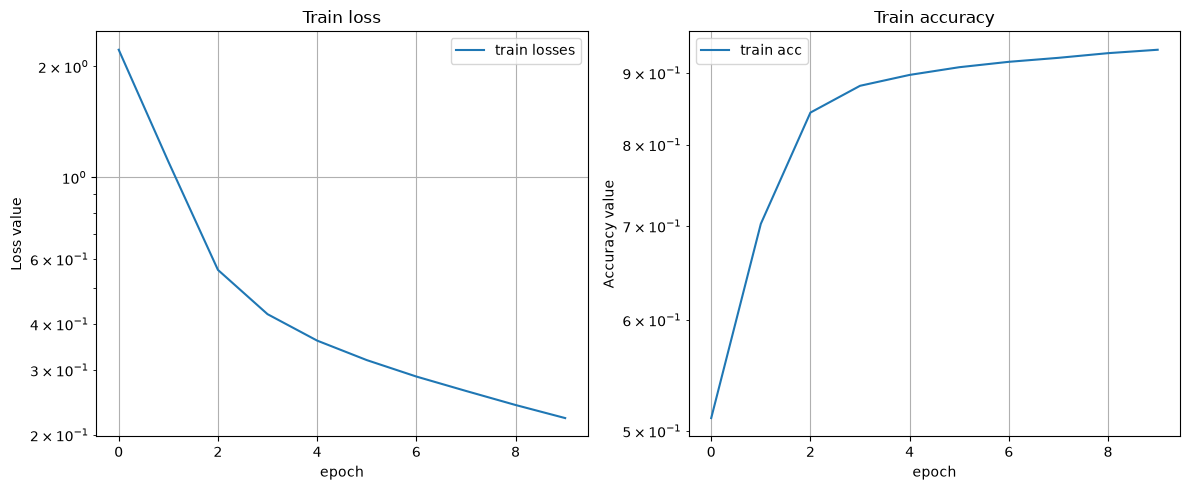

In [18]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label="train losses")

plt.yscale("log")
plt.xlabel("epoch")
plt.ylabel("Loss value")
plt.title("Train loss")
plt.legend()
plt.grid(True)


plt.subplot(1, 2, 2)
plt.plot(train_accs, label="train acc")

plt.yscale("log")
plt.xlabel("epoch")
plt.ylabel("Accuracy value")
plt.title("Train accuracy")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

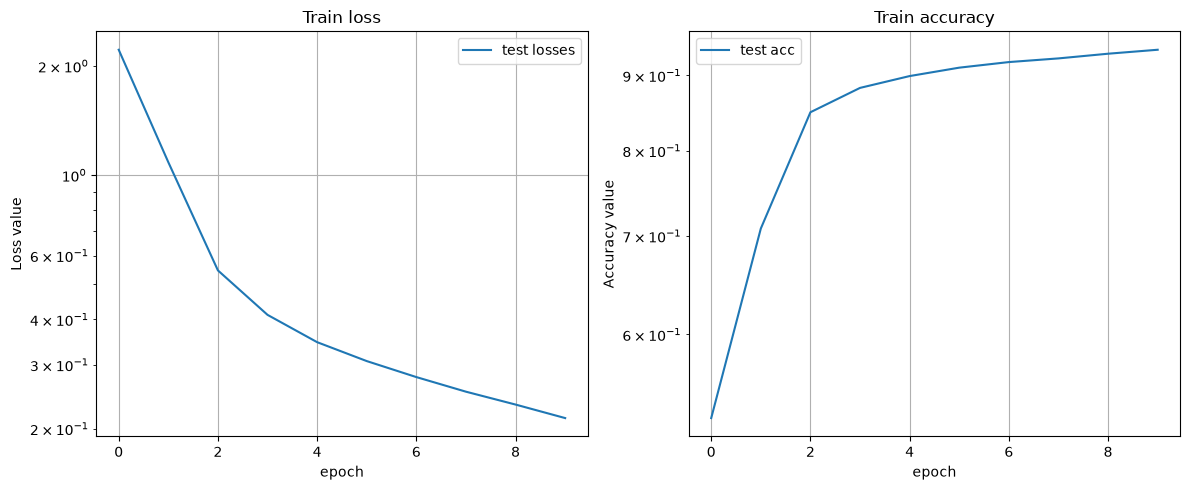

In [19]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(test_losses, label="test losses")

plt.yscale("log")
plt.xlabel("epoch")
plt.ylabel("Loss value")
plt.title("Train loss")
plt.legend()
plt.grid(True)


plt.subplot(1, 2, 2)
plt.plot(test_accs, label="test acc")

plt.yscale("log")
plt.xlabel("epoch")
plt.ylabel("Accuracy value")
plt.title("Train accuracy")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

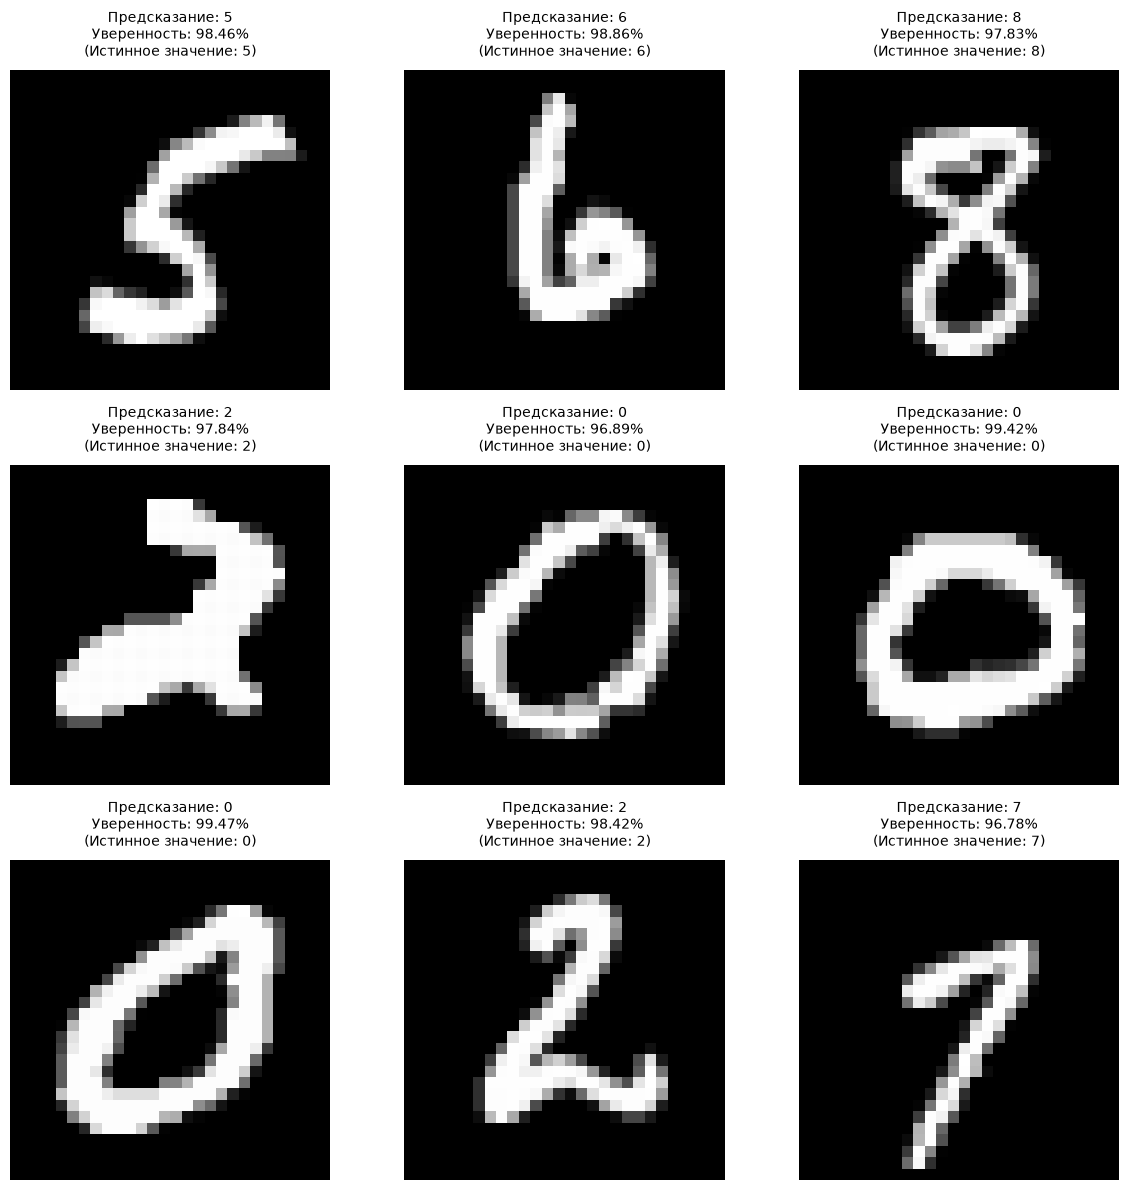

In [20]:
def visualize_predictions(model, dataset, device='cpu', num_images=9):
    """
    Визуализирует предсказания модели на случайных изображениях
    """
    model.eval()

    # Выбираем 9 случайных индексов
    indices = random.sample(range(len(dataset)), num_images)

    # Создаем subplot 3x3
    fig, axes = plt.subplots(3, 3, figsize=(12, 12))
    axes = axes.ravel()  # Преобразуем в 1D массив для удобства

    with torch.no_grad():
        for i, idx in enumerate(indices):
            # Получаем изображение и истинную метку
            image, true_label = dataset[idx]

            # Подготавливаем изображение для модели
            image_batch = image.unsqueeze(0).to(device)  # Добавляем batch dimension

            # Получаем предсказание
            logits = model(image_batch)
            probabilities = F.softmax(logits, dim=1)

            # Находим предсказанный класс и уверенность
            predicted_class = torch.argmax(probabilities, dim=1).item()
            confidence = torch.max(probabilities).item()

            # Отображаем изображение
            # Убираем padding для визуализации (возвращаем к 28x28)
            image_np = image.squeeze().numpy()
            if image_np.shape == (32, 32):  # Если есть padding
                image_np = image_np[2:30, 2:30]  # Обрезаем padding

            axes[i].imshow(image_np, cmap='gray')
            axes[i].axis('off')

            # Создаем заголовок с предсказанием и уверенностью
            title = f'Предсказание: {predicted_class}\nУверенность: {confidence:.2%}\n(Истинное значение: {true_label})'
            axes[i].set_title(title, fontsize=10, pad=10)

    plt.tight_layout()
    plt.show()

visualize_predictions(model_lenet, test_ds, device, num_images=9)

### Residual / Skip Connection

Остаточное соединение добавляет вход $x$ к выходу обучаемой ветви $F(x)$:

$$
y = F(x) + x
$$

Блок учит поправку $F(x)=H(x)-x$ к входному представлению. Прямой путь помогает передавать сигнал и градиенты через глубокую сеть, но не гарантирует отсутствие затухания или взрыва градиентов.

Для сложения формы обеих ветвей должны совпадать. Если они различаются, вход преобразуют проекцией.


![Skip-connection](https://theaisummer.com/static/8d19d048cd68d6dce362e025cf3b635a/1ac66/skip-connection.png)

### ResNet

ResNet (Residual Network) – семейство свёрточных сетей с остаточными связями (skip-connections), предложенное [He et al](https://www.cv-foundation.org/openaccess/content_cvpr_2016/papers/He_Deep_Residual_Learning_CVPR_2016_paper.pdf) на конференции CVPR’16.

#### Блоки и линейки

- **BasicBlock (ResNet-18/34)** – два `3×3` conv. Лёгкий и быстрый.
- **Bottleneck (ResNet-50/101/152)** – `1×1 → 3×3 → 1×1`: первый `1×1` сжимает каналы, последний расширяет (обычно коэффициент ×4). Дает глубокие сети при умеренных FLOPs.
- Если меняются пространственные размеры или число каналов, **shortcut** делают проекцией `1×1`. При уменьшении пространственных размеров используют `stride > 1`; при изменении только числа каналов достаточно `stride = 1`.

#### Почему ResNet — стандартный бэкбон

- Легко масштабируется по глубине/ширине и переносится между задачами.
- Совместим с детекцией/сегментацией: **FPN** строит пирамиду по выходам стейджей (C2–C5).
- Отличный компромисс «качество/стоимость»:  
  **ResNet-18** – мобайл/edge, **ResNet-50** – «рабочая лошадка», **ResNet-101/152** – максимум точности.

In [21]:
class ResidualBlock(nn.Module):
    """
    Простой residual блок: x -> conv -> relu -> conv -> + x -> relu
    """
    def __init__(self, channels):
        super().__init__()
        self.conv1 = nn.Conv2d(channels, channels, kernel_size=3, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(channels)
        self.conv2 = nn.Conv2d(channels, channels, kernel_size=3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(channels)

    def forward(self, x):
        # Сохраняем оригинальный вход (это и есть residual connection!)
        residual = x

        # Основной путь
        out = self.conv1(x)
        out = self.bn1(out)
        out = F.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        # Добавляем residual connection: F(x) + x
        out = out + residual  # ← ЭТО ГЛАВНОЕ!

        # Финальная активация
        out = F.relu(out)

        return out


class SimpleResNet(nn.Module):
    def __init__(self, num_classes=10, num_blocks=3):
        super().__init__()

        # Начальная обработка: 1 -> 64 каналов
        self.initial_conv = nn.Conv2d(1, 64, kernel_size=7, padding=3, bias=False)
        self.initial_bn = nn.BatchNorm2d(64)

        # Residual блоки
        self.residual_blocks = nn.ModuleList([
            ResidualBlock(64) for _ in range(num_blocks)
        ])

        # Глобальный average pooling + классификатор
        self.global_pool = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Linear(64, num_classes)

    def forward(self, x):
        # Начальная обработка
        x = self.initial_conv(x)
        x = self.initial_bn(x)
        x = F.relu(x)

        # Проходим через residual блоки
        for block in self.residual_blocks:
            x = block(x)  # Здесь происходит F(x) + x

        # Финальная классификация
        x = self.global_pool(x)  # (N, 64, 1, 1)
        x = x.view(x.size(0), -1)  # (N, 64)
        x = self.classifier(x)

        return x

### Fine-tuning

Дообучение (fine-tuning) – это процесс адаптации уже предварительно обученной нейронной сети для решения новой, специфической задачи.

Представьте, что у вас есть модель, которая уже научилась распознавать общие признаки изображений на миллионах фотографий.

Вместо того чтобы обучать новую сеть с нуля для распознавания, скажем, пород собак, вы берете эту готовую модель и "доучиваете" её на меньшем наборе данных с собаками.
Дообучение работает благодаря тому, что нижние слои нейронной сети изучают базовые признаки (края, текстуры, простые формы), которые универсальны для многих задач.

Верхние слои специализируются на конкретной задаче. При дообучении мы можем либо обучать всю сеть на новых данных с очень малой скоростью обучения, либо заморозить часть весов и обучать только верхние слои.

Преимущества дообучения очевидны: значительно меньше времени и вычислительных ресурсов, меньше данных для обучения, и часто лучшее качество результата, особенно когда у вас ограниченный набор данных.

Давайте возьмем предобученную ResNet18 (обученную на ImageNet) и адаптируем её для классификации пород кошек и собак.

Модель уже знает базовые визуальные признаки, нам нужно только научить её различать породы.

Нам надо заменить стандартную голову ResNet (1000 классов ImageNet) на новую голову с 37 выходами для наших пород кошек и собак.

In [22]:
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                        std=[0.229, 0.224, 0.225])  # ImageNet нормализация
])

val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                        std=[0.229, 0.224, 0.225])
])


train_dataset = datasets.OxfordIIITPet(
    root='./data',
    split='trainval',
    target_types='category',
    download=True,
    transform=train_transforms
)

test_dataset = datasets.OxfordIIITPet(
    root='./data',
    split='test',
    target_types='category',
    download=True,
    transform=val_transforms
)

100%|██████████| 792M/792M [00:30<00:00, 26.0MB/s] 
100%|██████████| 19.2M/19.2M [00:01<00:00, 16.4MB/s]


In [23]:
batch_size = 1024
num_classes = len(train_dataset.classes)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [24]:
print(f"Сколько пород кошек и собак (классов): {len(train_dataset.classes)}")
print(f"Длина train выборки: {len(train_dataset)}")
print(f"Длина test выборки: {len(test_dataset)}")

Сколько пород кошек и собак (классов): 37
Длина train выборки: 3680
Длина test выборки: 3669


In [25]:
def train_model(model, train_loader, test_loader, criterion, optimizer, scheduler,
                device, num_epochs, train_dataset_size, test_dataset_size):
    """
    Функция обучения модели с прогресс-барами и визуализацией

    Args:
        model: PyTorch модель
        train_loader: DataLoader для обучающих данных
        test_loader: DataLoader для валидационных данных
        criterion: функция потерь
        optimizer: оптимизатор
        scheduler: планировщик скорости обучения
        device: устройство (cpu/cuda)
        num_epochs: количество эпох
        train_dataset_size: размер обучающего датасета
        test_dataset_size: размер валидационного датасета

    Returns:
        dict: история обучения с потерями и точностью
    """

    # Инициализация истории обучения
    history = {
        'train_loss': [],
        'train_acc': [],
        'val_loss': [],
        'val_acc': []
    }

    for epoch in range(num_epochs):
        print(f'\nЭпоха {epoch+1}/{num_epochs}')
        print('-' * 50)

        # === ФАЗА ОБУЧЕНИЯ ===
        model.train()
        running_loss = 0.0
        running_corrects = 0

        # Прогресс-бар для обучения
        train_pbar = tqdm(train_loader, desc=f'Обучение эпоха {epoch+1}',
                         leave=False, dynamic_ncols=True)

        for inputs, labels in train_pbar:
            inputs = inputs.to(device)
            labels = labels.to(device)

            # Обнуляем градиенты
            optimizer.zero_grad()

            # Прямой проход
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            loss = criterion(outputs, labels)

            # Обратный проход и оптимизация
            loss.backward()
            optimizer.step()

            # Статистика
            batch_loss = loss.item() * inputs.size(0)
            batch_corrects = torch.sum(preds == labels.data)

            running_loss += batch_loss
            running_corrects += batch_corrects

            # Обновляем прогресс-бар
            current_acc = batch_corrects.double() / inputs.size(0)
            train_pbar.set_postfix({
                'loss': f'{loss.item():.4f}',
                'acc': f'{current_acc:.4f}'
            })

        # Средние метрики за эпоху обучения
        epoch_train_loss = running_loss / train_dataset_size
        epoch_train_acc = running_corrects.double() / train_dataset_size

        # === ФАЗА ВАЛИДАЦИИ ===
        model.eval()
        val_running_loss = 0.0
        val_running_corrects = 0

        val_pbar = tqdm(test_loader, desc=f'Валидация эпоха {epoch+1}',
                       leave=False, dynamic_ncols=True)

        with torch.no_grad():
            for inputs, labels in val_pbar:
                inputs = inputs.to(device)
                labels = labels.to(device)

                outputs = model(inputs)
                _, preds = torch.max(outputs, 1)
                loss = criterion(outputs, labels)

                batch_loss = loss.item() * inputs.size(0)
                batch_corrects = torch.sum(preds == labels.data)

                val_running_loss += batch_loss
                val_running_corrects += batch_corrects

                # Обновляем прогресс-бар
                current_acc = batch_corrects.double() / inputs.size(0)
                val_pbar.set_postfix({
                    'loss': f'{loss.item():.4f}',
                    'acc': f'{current_acc:.4f}'
                })

        # Средние метрики за эпоху валидации
        epoch_val_loss = val_running_loss / test_dataset_size
        epoch_val_acc = val_running_corrects.double() / test_dataset_size

        # Сохраняем историю
        history['train_loss'].append(epoch_train_loss)
        history['train_acc'].append(epoch_train_acc.item())
        history['val_loss'].append(epoch_val_loss)
        history['val_acc'].append(epoch_val_acc.item())

        # Выводим результаты эпохи
        print(f'Обучение   - Потери: {epoch_train_loss:.4f} Точность: {epoch_train_acc:.4f}')
        print(f'Валидация  - Потери: {epoch_val_loss:.4f} Точность: {epoch_val_acc:.4f}')
        print(f'LR: {scheduler.get_last_lr()[0]:.2e}')

        # Обновляем планировщик
        scheduler.step()

    return history

#### Шаг 1. Загрузка ResNet18

In [26]:
model = models.resnet18(weights='IMAGENET1K_V1')
print(model)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /home/markblumenau/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 83.1MB/s]

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

#### Шаг 2. Заменяем голову на свою.

In [27]:
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, len(train_dataset.classes))

In [28]:
# Давайте еще раз посмотрим на нашу модель
print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

#### Шаг 3. Дообучение

In [29]:
model = model.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)

In [30]:
history_finetune = train_model(
    model=model,
    train_loader=train_loader,
    test_loader=test_loader,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    device=device,
    num_epochs=10,
    train_dataset_size=len(train_dataset),
    test_dataset_size=len(test_dataset)
)



Эпоха 1/10
--------------------------------------------------


Обучение эпоха 1:   0%|          | 0/4 [00:00<?, ?it/s]

Валидация эпоха 1:   0%|          | 0/4 [00:00<?, ?it/s]

Обучение   - Потери: 3.6236 Точность: 0.0633
Валидация  - Потери: 3.0624 Точность: 0.1693
LR: 1.00e-04

Эпоха 2/10
--------------------------------------------------


Обучение эпоха 2:   0%|          | 0/4 [00:00<?, ?it/s]

...

Валидация эпоха 9:   0%|          | 0/4 [00:00<?, ?it/s]

Обучение   - Потери: 0.7353 Точность: 0.9022
Валидация  - Потери: 0.9043 Точность: 0.8272
LR: 1.00e-05

Эпоха 10/10
--------------------------------------------------


Обучение эпоха 10:   0%|          | 0/4 [00:00<?, ?it/s]

Валидация эпоха 10:   0%|          | 0/4 [00:00<?, ?it/s]

Обучение   - Потери: 0.7204 Точность: 0.9101
Валидация  - Потери: 0.9048 Точность: 0.8324
LR: 1.00e-05


In [31]:
torch.save(model.state_dict(), 'model_weights.pth')

print("Model weights saved successfully!")

Model weights saved successfully!


### Заморозка весов

Заморозка весов (weight freezing) – это техника, при которой параметры определенных слоев нейронной сети фиксируются и не обновляются во время обучения.
Замороженные веса остаются неизменными, в то время как остальная часть сети продолжает обучаться.

Эта техника особенно полезна при дообучении. Например, если вы используете предобученную модель ResNet для классификации медицинских изображений, вы можете заморозить веса нижних слоев (которые распознают базовые визуальные признаки) и обучать только верхние слои, специфичные для медицинской диагностики.

Заморозка весов помогает предотвратить "катастрофическое забывание" – ситуацию, когда сеть теряет ранее изученные полезные представления при обучении на новой задаче. Также это ускоряет обучение и снижает требования к памяти, поскольку градиенты вычисляются только для незамороженных слоев.

#### Шаг 1. Загружаем модель

In [32]:
freeze_model = models.resnet18(weights='IMAGENET1K_V1')
print("Загружена предобученная ResNet18")

Загружена предобученная ResNet18


#### Шаг 2. Замораживаем backbone.

In [33]:
print("Замораживаем веса бекбона...")
for param in freeze_model.parameters():
    param.requires_grad = False
print("Веса backbone заморожены")

Замораживаем веса бекбона...
Веса backbone заморожены


#### Шаг 3. Также заменяем предобученную голову на свою

In [34]:
num_features = freeze_model.fc.in_features
freeze_model.fc = nn.Linear(num_features, len(train_dataset.classes))

#### Шаг 4. Обучение только головы

In [35]:
freeze_model = freeze_model.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(freeze_model.parameters(), lr=1e-3) # Важно обратить внимание! Когда мы дообучаем веса, то LR должен быть маленьким, чтобы не вылететь из локального минимума
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)

In [36]:
history_freeze = train_model(
    model=freeze_model,
    train_loader=train_loader,
    test_loader=test_loader,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    device=device,
    num_epochs=10,
    train_dataset_size=len(train_dataset),
    test_dataset_size=len(test_dataset)
)


Эпоха 1/10
--------------------------------------------------


Обучение эпоха 1:   0%|          | 0/4 [00:00<?, ?it/s]

Валидация эпоха 1:   0%|          | 0/4 [00:00<?, ?it/s]

Обучение   - Потери: 3.5609 Точность: 0.0519
Валидация  - Потери: 3.1984 Точность: 0.1769
LR: 1.00e-03

Эпоха 2/10
--------------------------------------------------


Обучение эпоха 2:   0%|          | 0/4 [00:00<?, ?it/s]

...

Валидация эпоха 9:   0%|          | 0/4 [00:00<?, ?it/s]

Обучение   - Потери: 1.2808 Точность: 0.8253
Валидация  - Потери: 1.3519 Точность: 0.7871
LR: 1.00e-04

Эпоха 10/10
--------------------------------------------------


Обучение эпоха 10:   0%|          | 0/4 [00:00<?, ?it/s]

Валидация эпоха 10:   0%|          | 0/4 [00:00<?, ?it/s]

Обучение   - Потери: 1.2669 Точность: 0.8264
Валидация  - Потери: 1.3416 Точность: 0.7880
LR: 1.00e-04


In [37]:
torch.save(freeze_model.state_dict(), 'model_freeze.pth')

print("Model weights saved successfully!")

Model weights saved successfully!


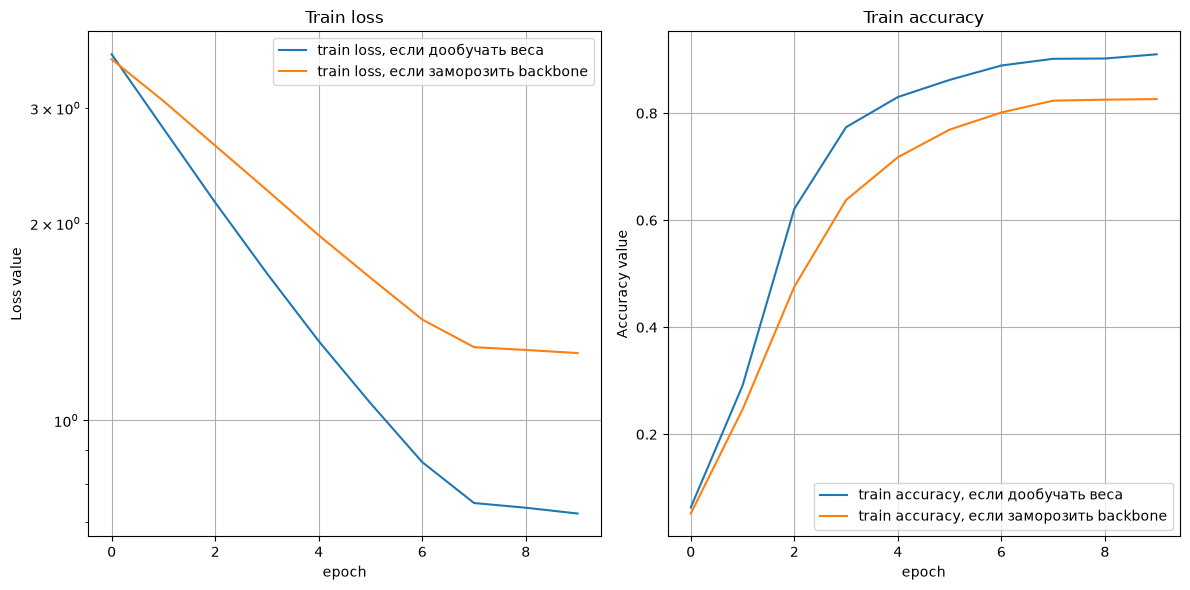

In [38]:
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(history_finetune['train_loss'], label="train loss, если дообучать веса")
plt.plot(history_freeze['train_loss'], label="train loss, если заморозить backbone")

plt.yscale("log")
plt.xlabel("epoch")
plt.ylabel("Loss value")
plt.title("Train loss")
plt.legend()
plt.grid(True)


plt.subplot(1, 2, 2)
plt.plot(history_finetune['train_acc'], label="train accuracy, если дообучать веса")
plt.plot(history_freeze['train_acc'], label="train accuracy, если заморозить backbone")

plt.xlabel("epoch")
plt.ylabel("Accuracy value")
plt.title("Train accuracy")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

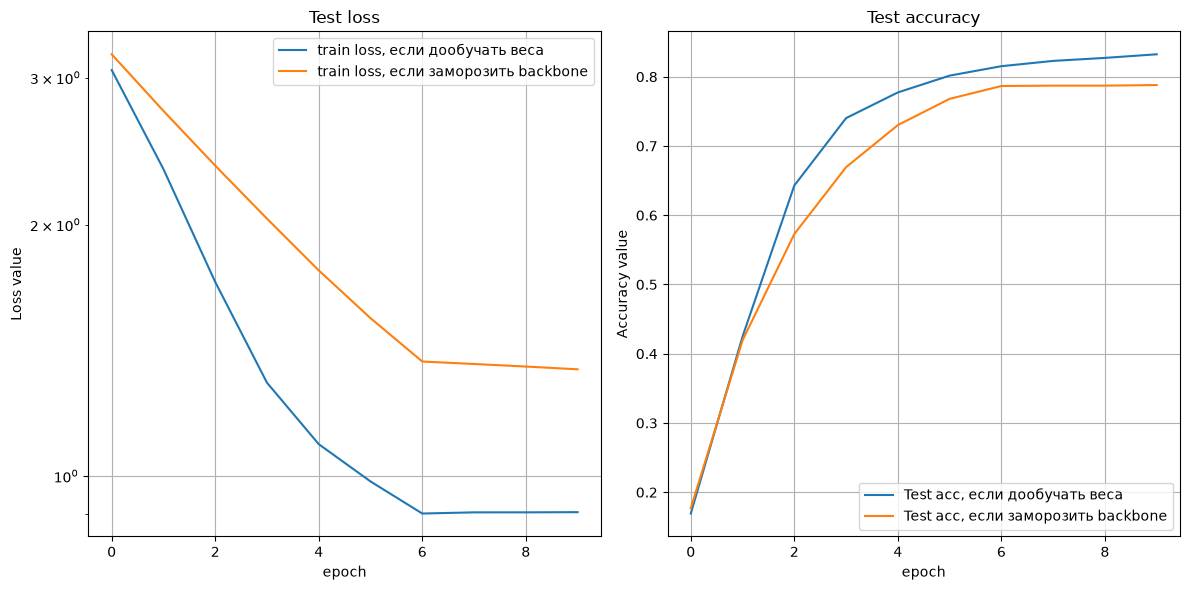

In [39]:
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(history_finetune['val_loss'], label="train loss, если дообучать веса")
plt.plot(history_freeze['val_loss'], label="train loss, если заморозить backbone")

plt.yscale("log")
plt.xlabel("epoch")
plt.ylabel("Loss value")
plt.title("Test loss")
plt.legend()
plt.grid(True)


plt.subplot(1, 2, 2)
plt.plot(history_finetune['val_acc'], label="Test acc, если дообучать веса")
plt.plot(history_freeze['val_acc'], label="Test acc, если заморозить backbone")

plt.xlabel("epoch")
plt.ylabel("Accuracy value")
plt.title("Test accuracy")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

Разные ситуации требуют разных решений. Если у нас мало GPU memory и не хочется тратить много своих ресурсов, то стоит рассмотреть заморозку backbone и обучать только классификационную голову.

Но в реальности, уже мало кто замораживает backbone, все сейчас фантюнят модели. Например SFT в LLMках.

### Визуализация

In [40]:
IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
IMAGENET_STD  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)

def denormalize_batch(x):
    # x: (B,3,H,W), torch.Tensor on CPU/GPU
    return (x * IMAGENET_STD.to(x.device) + IMAGENET_MEAN.to(x.device)).clamp(0,1)


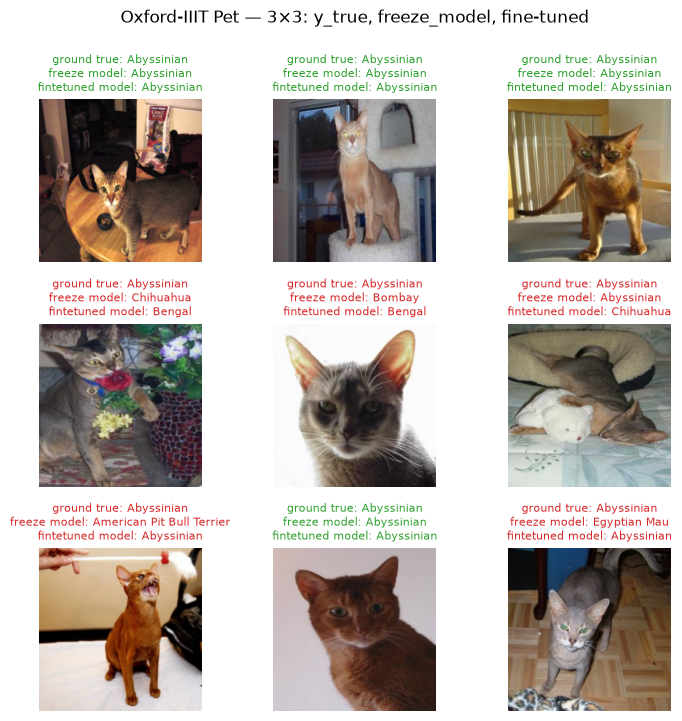

In [41]:
@torch.no_grad()
def visualize_grid(freeze_model, model, data_loader, device):
    freeze_model.eval().to(device)
    model.eval().to(device)

    # берём один большой батч
    images, targets = next(iter(data_loader))
    images  = images.to(device)
    targets = targets.to(device)

    # ограничимся 81 образцом
    show_n = min(81, images.size(0))
    images  = images[:show_n]
    targets = targets[:show_n]

    # предсказания двух моделей
    logits_freeze = freeze_model(images)
    logits_model  = model(images)
    preds_freeze  = logits_freeze.argmax(1)
    preds_model   = logits_model.argmax(1)

    # денорм для отображения (на CPU)
    imgs_vis = denormalize_batch(images).cpu().numpy()

    rows = cols = 3
    fig, axes = plt.subplots(rows, cols, figsize=(2.4*cols, 2.4*rows))
    axes = np.array(axes).reshape(rows, cols)

    for i in range(rows * cols):
        ax = axes[i // cols, i % cols]
        if i < show_n:
            img = np.transpose(imgs_vis[i], (1, 2, 0))
            ax.imshow(img)
            ax.axis("off")

            y = targets[i].item()
            p1 = preds_freeze[i].item()
            p2 = preds_model[i].item()
            y_name  = test_dataset.classes[y]
            p1_name = test_dataset.classes[p1]
            p2_name = test_dataset.classes[p2]

            both_ok = (p1 == y) and (p2 == y)
            color = "tab:green" if both_ok else "tab:red"

            ax.set_title(
                f"ground true: {y_name}\n"
                f"freeze model: {p1_name}\n"
                f"fintetuned model: {p2_name}",
                fontsize=8, color=color
            )
        else:
            ax.axis("off")

    fig.suptitle("Oxford-IIIT Pet — 3×3: y_true, freeze_model, fine-tuned", y=0.995)
    plt.tight_layout()
    plt.show()


visualize_grid(freeze_model, model, test_loader, device)

## RNN и LSTM

### RNN: одно состояние на всю историю

В последовательности важен порядок: символы `el` и `le` задают разные начала имени. **RNN** читает элементы по шагам и передаёт между ними скрытое состояние:

$$h_t = \tanh(W_x x_t + W_h h_{t-1} + b).$$

Один набор весов используется на всех шагах. Состояние $h_t$ содержит обучаемое представление уже прочитанного префикса. По нему предсказываем следующий символ.

При обратном распространении сеть разворачивается в цепочку шагов по времени. На длинных цепочках градиенты могут затухать или взрываться. Это одна из причин, по которым обычной RNN трудно обучаться длинным зависимостям.


In [42]:
import time
import torch
from torch import nn
import matplotlib.pyplot as plt

torch.manual_seed(42)
rnn_device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if rnn_device.type == "cpu":
    torch.set_num_threads(min(2, torch.get_num_threads()))
print("Устройство практики:", rnn_device)


Устройство практики: cuda


In [43]:
# Источник: https://github.com/xiyori/intro-to-dl-hse/blob/2024-2025/seminars/intro_to_dl/week_7/223/elvish-names.pickle
rnn_names = """
abadda abarat adamar adorellan adresin aduce aelieyeeva aelrindel
aelrue aelynthi aerendyl aerilaya aermhar aesar aeson afamrail
agis aglanthol ahrendaaria ahrendue ahskahala ainesilver aithlin ajaar
ajhalanda akhelbhen akkar alabyran alaglossa alais alauthshaee alavara
albondiel alea alerathla alinar allain allannia allisa alloralla
allynna almithara aloevan aloiene alok alosrin althidon aluendalee
alvaerele alyndra amara amaranthae amkissra amlaruil amnestria amra
amrynn anaharae anarallath anarzee andaerean andrathath aneirin anfalen
anhaern anlyth anyllan aolis aquilan ara araevin arandron
araushnee aravae aravilar arbane arcaena ardreth ardryll argus
arielimnda arkhun arkiem arl arlayna arlen arnarra artin
arun ascal ashemmi athtar aubaudameira aubric aubron aulathar
aulauthar auluua aumanas aumrauth aurae ava avourel axilya
ayaeqlarune azariah baerdelcoam baerithryn belanor beldroth bellas belstram
beluar bhuraelea bhyrindaar biafyndar bialaer blythswana bonnalurie braerindra
braern brindarry buttorwyr caerthynna calarel cameron cauladra chaalmyth
chaenath chalsarda chandrelle chasianna chathanglas cheyrth chichlandra chinnesstre
chomylla chozzaster chylnoth cilivren ciyradyl claire cluhurach cluym
cohnal conall connak corellon cornaith corym csharynn cymbiir
cystenn daenalaia dakath dalyor dannyd daratrine daratrine darcassan
darfin darshee darthoridan dasyra dathlue dathlue dathlue deldrach
delimbiyra delmuth delsaran delshandra deryth deularla dhoelath divisav
drannor droth druindar duilya durlan durothil dyffros eallyrl
earynspieir ecaeris edansyr edicuve edraele edwyrd edyrm ehlark
ehrendil eilauver elaethan elaith elanalue elandorr elanil elanjar
elasha elashor elbauthin elbereth eldaernth eldar eldratha eldrin
elenaril elenaril elenshaer elephon eletha elhieardacil elidyr elion
elkhazel ellarian ellifain ellisar eloen elora elorfindar elorshin
elpaerae eltaor eltargrim elvandaruil embrae emmyth emvorele enajharas
entrydal erendriel erglareo eriladar erlan erlathan eroan erolith
eschallus eshenesra essaerae esta estelar ester esyae ethlando
ettrian euchoe evindal eyrynnhv faahresc faelar faelyn faeranduil
falael faoraar faranni faunalyn felaern felarathael fenian fflar
fhaertala fhaornik fhociin fieryat filarion filaurel filauria fildaerae
filvendor filverel finufaranell flardryn flinar foxattwilight foxfire francessca
fylson gaeleath gaelin gaelira gaerradh galaeron galan galather
ganamede gantar garrik garynnon gaylia gemstarzah ghilanna giilvas
giullio glarald glorandal glynnii goronyyv grathgor gweyr gwynnestri
gylledha haalaari haalija hacathra hachaam haemir haladavar halaema
halaema halafarin halama halamar halanaestra haldreithen halflar halgondas
halpaeril halueth halueve hamalitia haramara haryk hasterien hastos
hatharal helartha hhora hiflanyl hoccar holone horith hubyr
huquethae hycis iahalae ialantha iefyr ievos ievos ihimbraskar
ikeshia ilbryn ildilyntra ilimitar iliphar ilitharath illianaro illithor
illitran ilmadia ilphas ilrune ilsevel ilthuryn ilyndrathyl ilyrana
ilyrana ilythyrra imdalace imizael immianthe immianthe imra imramarthree
imryll inchel inialos injros innovindil intevar ioelena iolas
iolrath irhaal isciira isilfarrel itham ithraides ithrythra itiireae
itylra ivlisar ivosaar ivran iymbryl iyrandrar iyriklaunavan jandar
jannalor jaonos jassin jastra jeardra jhaan jhaartael jhaer
jhaeros jhalass jhanandra jharak jharym jhaumrithe jhiilsraa jhuvik
jonas jonik jorildyn josidiah juppar kahvoerm kalaerede katar
katyr kavrala kaylessa keerla keishara keletheryl kelvhan kendel
kerym keryth kesefehon kethryllia keya khaalindaan kharis khatar
khidell khiipaera khiiral khilseith khuumal khyrmn khyssoun kileontheal
kindroth kivessin kiyuigh klaern kolvar korrigash kroloth kuornos
kuskyn kuskyn kymil kyrtaar kythaela laamtora laerdya laeroth
laerune lafarallin lamruil laosx larongar larrel lashrael lashul
lathai lathlaeril laurlaethee lazziar leayonadas leilatha leojym lhombaerth
lhoris lianthorn liluth llamryl llarm llewellenar llombaerth lorelei
lorsan luirlan luthais luvon lyari lydialeera lyklor lyraesel
lysanthir maaleshiira maasli maelyrra maendellyn maeraddyth maeral maeralya
maiele maith makaela malgath malruthiia mardeiym marikoth mariona
marissa marlevaur martainn meira melandrach melarue melisander merellien
merethyl merialeth meriel merith merlara methild mhaenal mihangyl
miilaethorn miirphys mirthal mirthal mistale mitilarro mladris mlartlar
mlossae mnuvae molonym molostroi montagor morgan morgwais morthil
moryggan mothrys mourn muerlara mylaela mylaerla myrddin myriani
myriil myrin myronthilar mythanthar naertho naeryndam naeryndam naevys
nakiasha nambra namyriitha nanalethalee nanthee nanthleene napraeleon narbeth
nardual naumys nelaeryn nelaeryn neldor neldor nesterin nevarth
nhamashal nieven nindrol ninthalor nlaea nlossae nopos norlorn
nremyn nuala nueleth nuovis nushala nuvian nyaalsir nylaathria
nylian nym nyvorlas oacenth ochyllyss oenel ohmbryn olaurae
olinsivver olithir oluevaera onas oncith ondabrar ondroth onvyr
orist orlpar orndacil ornthalas ornthalas ortaure orym oslarelar
otaehryn otaerhyn othorion paeral paeris passilorris paulorin phaendar
phaerl phantyni pharom phelorna phraan phuingara phyrra pirphal
pleufan pollae puorlaas purtham pyrder pyrravym pywaln pyxaanthal
qemba qildor quamara quastarte quynn raejiisa raeranthur raerauntha
raibyr ralikanthae ralnor rathal rathiain raunaeril rauthomyr rauvelore
reluraun reluvethel renestrae rennyn reptar respen rhaacvar rhalyf
rhangyl rhenalyrr rhespen rhistel rhothomir rhys rilitar riluaneth
roanmara rolim rotheloe rothilion ruardh ruavia rubrae ruehar
ruith rumathil ruvaen ruven ruvyn rychell ryfon ryllae
ryul ryvvik sadalymn saelethil saelihn saelihn saevel saevel
saida sakaala sakrattars sakrattars samblar sandevv sariandi sarya
schimae seanchai seirye seith seiveril selanlar seldanna selgauth
selussa seonais shadowmoon shael shael shalana shalantha shalendra
shalheira shammath shandalar shanyrria sharaera sharian sharian sharlario
shaundyl sheedra sheera shevarash shialaevar shialaevar shilarra shonassir
shoulree shyael shyael shyllisyrr shyrrik siirist silvyr simimar
sinaht sinaht sinnafain skalanis skalanis soliania sontar soora
sorsasta srindin strohm sudryl sudryl sundamar susklahava sylleth
sylmae sylvar symkalr symrustar syndra synnorha syrune sythaeryn
sythaeryn syviis taanyth taegen taeglyn taenaran taenya taeral
taerntym takari talaedra talanashta taleisin talila talindra tamara
tammson tamnaeuth tamnaeuth tamsin tanithil tannivh tannivh tannyll
tanseril tanyl tanyl taranath tarasynora tarathiel tarathiel taredd
tarosspur tarron tasar tassarion tathaln teharissa tehlmar teirist
tenyajn teryani tethir thalaera thalanil thalanil thallan thaola
thasitalia thatoryl thiilthan throleatha thurdan thurruvyn tiarshus tiatha
tiraallara tiriara tisharu tkaron tlannatar tolthe tolthe tordynnar
toross traeliorn traeliorn travaran triandal triktappic tsaer tsarra
tsiilmas tyllaetha tyvollus ualair uevareth uldreiyn uldreiyn ulelesse
unae urddusk urmicca uschymna usunaar uthorim vaalyun vaeril
vaervenshalice valindra valmaxian vander vartan vashti velaethaunyl velatha
velethuil veluthil venali verrona vesperr vesryn vesstan vestele
vhoadan vhoorhin vhoori viansola volodar voron waernas winterflower
wistari wylchyr wylym wyn wyndelleu wyqhael wyrran xalph
xanotter xhalh xhalth xharlion xiiltharra yaereene yalanilue yalathanil
yathlanae yeschant yeshelne yghiilra ygrainne yhendorn ylyndar ynloeth
ynshael yrlissa yrneha yrthraethra ysmyrlda ytharra yulmanda zabbas
zaltarish zandro zaor zaos zberyl zelphar zhoron zhuirentel
zoastria zulae
""".split()

print("Имён:", len(rnn_names))
print("Примеры:", rnn_names[:10])


Имён: 914
Примеры: ['abadda', 'abarat', 'adamar', 'adorellan', 'adresin', 'aduce', 'aelieyeeva', 'aelrindel', 'aelrue', 'aelynthi']


### Из имени в обучающие пары

Каждый символ получает целочисленный индекс. Добавим три служебных токена: `<bos>` для начала, `<eos>` для конца и `<pad>` для выравнивания длины в батче.

Для имени `abadda` входом будет `<bos> a b a d d a`, а целевым ответом `a b a d d a <eos>`. На каждом шаге сеть предсказывает следующий символ. В обучении она получает правильный префикс; это называется **teacher forcing**.

Дополнение `<pad>` понадобится только для общей формы тензоров. Его позиции исключим из функции потерь. `nn.Embedding` превратит индекс символа в обучаемый вектор; численное значение индекса само по себе не задаёт сходство символов.


In [44]:
rnn_vocab = ["<pad>", "<bos>", "<eos>"] + sorted(set("".join(rnn_names)))
rnn_stoi = {token: index for index, token in enumerate(rnn_vocab)}
RNN_PAD, RNN_BOS, RNN_EOS = 0, 1, 2
rnn_vocab_size = len(rnn_vocab)
rnn_max_length = max(map(len, rnn_names)) + 2

rnn_tokens = torch.full((len(rnn_names), rnn_max_length), RNN_PAD, dtype=torch.long)
for row, name in enumerate(rnn_names):
    ids = [RNN_BOS] + [rnn_stoi[char] for char in name] + [RNN_EOS]
    rnn_tokens[row, :len(ids)] = torch.tensor(ids)

rnn_inputs = rnn_tokens[:, :-1]
rnn_targets = rnn_tokens[:, 1:]
print("Словарь:", rnn_vocab)
print("Форма входа и целей:", rnn_inputs.shape, rnn_targets.shape)


Словарь: ['<pad>', '<bos>', '<eos>', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']
Форма входа и целей: torch.Size([914, 15]) torch.Size([914, 15])


In [45]:
example_length = len(rnn_names[0]) + 1
print("Вход:", [rnn_vocab[i] for i in rnn_inputs[0, :example_length].tolist()])
print("Цель:", [rnn_vocab[i] for i in rnn_targets[0, :example_length].tolist()])


Вход: ['<bos>', 'a', 'b', 'a', 'd', 'd', 'a']
Цель: ['a', 'b', 'a', 'd', 'd', 'a', '<eos>']


### Генератор: Embedding → RNN → Linear

При `batch_first=True` используем формы `[B, T] → [B, T, E] → [B, T, H] → [B, T, V]`, где `B` означает размер батча, `T` длину, `E` размер эмбеддинга, `H` размер скрытого состояния, `V` размер словаря.

`output` содержит скрытые состояния для **всех шагов**. `state` содержит финальное состояние и позволяет продолжить последовательность. У однослойной однонаправленной RNN оно имеет форму `[1, B, H]`. Параметр `batch_first` не меняет форму `state`.

Сделаем класс с переключателем: позже заменим `nn.RNN` на `nn.LSTM`, сохранив данные, выходной слой и функцию потерь.


In [46]:
class NameLanguageModel(nn.Module):
    def __init__(self, cell_type="rnn", embedding_dim=24, hidden_dim=64):
        super().__init__()
        self.embedding = nn.Embedding(rnn_vocab_size, embedding_dim, padding_idx=RNN_PAD)
        if cell_type == "rnn":
            self.recurrent = nn.RNN(embedding_dim, hidden_dim, batch_first=True)
        elif cell_type == "lstm":
            self.recurrent = nn.LSTM(embedding_dim, hidden_dim, batch_first=True)
        else:
            raise ValueError("cell_type должен быть rnn или lstm")
        self.head = nn.Linear(hidden_dim, rnn_vocab_size)

    def forward(self, tokens, state=None):
        embeddings = self.embedding(tokens)
        output, state = self.recurrent(embeddings, state)
        return self.head(output), state


In [47]:
torch.manual_seed(42)
name_rnn = NameLanguageModel("rnn").to(rnn_device)
with torch.no_grad():
    demo_logits, demo_state = name_rnn(rnn_inputs[:4].to(rnn_device))
print("Логиты:", tuple(demo_logits.shape))
print("Финальное h:", tuple(demo_state.shape))


Логиты: (4, 15, 29)
Финальное h: (1, 4, 64)


### Обучение: тот же backward, но через шаги последовательности

Передаём в `CrossEntropyLoss` логиты, без предварительного softmax. Объединим оси батча и времени: `[B, T, V] → [B·T, V]`. Цели превратим в `[B·T]`. `ignore_index` исключит позиции `<pad>`.

Применим ограничение нормы градиента (`clip_grad_norm_`) перед шагом оптимизатора: оно помогает при слишком больших градиентах, но не устраняет их затухание. После каждого батча начинаем новые независимые имена с нулевого состояния.

Для этой демонстрации используем весь корпус при обучении. Ошибка ниже характеризует подгонку обучающих имён, а не качество на новых данных.


In [48]:
def train_name_model(model, epochs=25, batch_size=64):
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
    criterion = nn.CrossEntropyLoss(ignore_index=RNN_PAD)
    order_generator = torch.Generator().manual_seed(123)
    losses = []
    started = time.perf_counter()
    model.train()
    for epoch in range(1, epochs + 1):
        order = torch.randperm(len(rnn_inputs), generator=order_generator)
        total_loss, total_tokens = 0.0, 0
        for indices in order.split(batch_size):
            inputs = rnn_inputs[indices].to(rnn_device)
            targets = rnn_targets[indices].to(rnn_device)
            optimizer.zero_grad()
            logits, _ = model(inputs)
            loss = criterion(logits.reshape(-1, rnn_vocab_size), targets.reshape(-1))
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            count = (targets != RNN_PAD).sum().item()
            total_loss += loss.item() * count
            total_tokens += count
        losses.append(total_loss / total_tokens)
        if epoch == 1 or epoch % 5 == 0:
            print(f"Эпоха {epoch:2d}: loss = {losses[-1]:.3f}")
    if rnn_device.type == "cuda":
        torch.cuda.synchronize()
    print(f"Время обучения: {time.perf_counter() - started:.1f} с")
    return losses


In [49]:
name_rnn_losses = train_name_model(name_rnn)


Эпоха  1: loss = 2.739
Эпоха  5: loss = 2.193
Эпоха 10: loss = 2.087
Эпоха 15: loss = 1.986
Эпоха 20: loss = 1.898
Эпоха 25: loss = 1.819
Время обучения: 0.5 с


### Генерация: теперь сеть получает свои ответы

Начинаем с `<bos>` или заданного префикса. Выбираем следующий символ из предсказанного распределения и подаём его обратно в сеть вместе с предыдущим состоянием. Останавливаемся на `<eos>` или при достижении ограничения длины.

Во время генерации правильного следующего символа уже нет. Это отличается от teacher forcing при обучении.

Температура управляет случайностью: перед softmax делим логиты на `temperature > 0`. Меньшая температура делает выбор более сосредоточенным, большая увеличивает разнообразие. Токены `<bos>` и `<pad>` исключаем из возможных продолжений.


In [50]:
@torch.no_grad()
def generate_name(model, prefix="", temperature=0.8, max_new_tokens=16):
    if temperature <= 0:
        raise ValueError("Температура должна быть положительной")
    if any(char not in rnn_stoi for char in prefix):
        raise ValueError("Префикс содержит символ вне словаря")
    model.eval()
    model_device = next(model.parameters()).device
    prefix_ids = [RNN_BOS] + [rnn_stoi[char] for char in prefix]
    tokens = torch.tensor([prefix_ids], device=model_device)
    logits, state = model(tokens)
    result = list(prefix)
    for _ in range(max_new_tokens):
        next_logits = logits[0, -1].clone() / temperature
        next_logits[RNN_PAD] = next_logits[RNN_BOS] = -torch.inf
        token_id = torch.multinomial(torch.softmax(next_logits, dim=-1), 1).item()
        if token_id == RNN_EOS:
            break
        result.append(rnn_vocab[token_id])
        # Продолжаем с сохранённым состоянием и только одним новым символом.
        tokens = torch.tensor([[token_id]], device=model_device)
        logits, state = model(tokens, state)
    return "".join(result)


In [51]:
torch.manual_seed(7)
for prefix in ["", "a", "el"]:
    samples = [generate_name(name_rnn, prefix=prefix) for _ in range(4)]
    print(f"Префикс {prefix!r}: {samples}")


Префикс '': ['sikutt', 'elbaeran', 'aeliss', 'clashaar']
Префикс 'a': ['aubryn', 'aelis', 'alonthue', 'arkaer']
Префикс 'el': ['elleth', 'elkevor', 'eltenni', 'elbaerth']


### LSTM: отдельная память и обучаемые вентили

У **LSTM** есть скрытое состояние $h_t$ и память $c_t$. Вентили вычисляются из текущего входа и предыдущего скрытого состояния; их значения после sigmoid лежат между 0 и 1.

$$
\begin{aligned}
c_t &= f_t \odot c_{t-1} + i_t \odot \widetilde c_t, \\
h_t &= o_t \odot \tanh(c_t).
\end{aligned}
$$

$f_t$ управляет сохранением старой памяти, $i_t$ записью новой, $o_t$ использованием памяти в скрытом состоянии. $\widetilde c_t$ является кандидатом на запись, а $\odot$ означает поэлементное умножение.

Аддитивное обновление памяти облегчает передачу информации и градиентов через много шагов, хотя не гарантирует идеальную память. В PyTorch `nn.LSTM` возвращает `output, (h_n, c_n)`. Формы обоих финальных состояний в нашем примере: `[1, B, H]`.

Теперь меняем только тип рекуррентного слоя и повторяем обучение на тех же данных. При одинаковом `hidden_dim` у LSTM больше параметров, поэтому это знакомство с архитектурами, а не сравнение при одинаковом вычислительном бюджете.


In [52]:
torch.manual_seed(42)
name_lstm = NameLanguageModel("lstm").to(rnn_device)
with torch.no_grad():
    lstm_logits, (lstm_h, lstm_c) = name_lstm(rnn_inputs[:4].to(rnn_device))
print("Логиты:", tuple(lstm_logits.shape))
print("h и c:", tuple(lstm_h.shape), tuple(lstm_c.shape))
print("Параметры RNN:", sum(p.numel() for p in name_rnn.parameters()))
print("Параметры LSTM:", sum(p.numel() for p in name_lstm.parameters()))


Логиты: (4, 15, 29)
h и c: (1, 4, 64) (1, 4, 64)
Параметры RNN: 8341
Параметры LSTM: 25621


In [53]:
name_lstm_losses = train_name_model(name_lstm)


Эпоха  1: loss = 2.841
Эпоха  5: loss = 2.213
Эпоха 10: loss = 2.081
Эпоха 15: loss = 1.935
Эпоха 20: loss = 1.772
Эпоха 25: loss = 1.608
Время обучения: 0.5 с


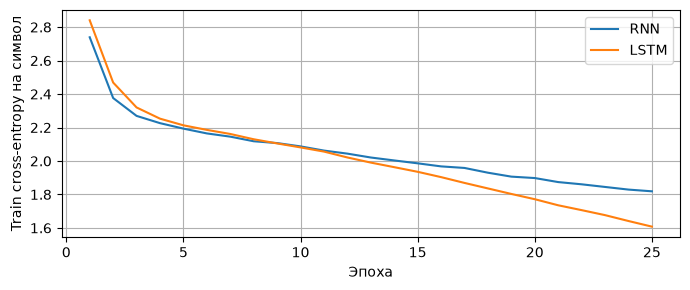

LSTM: ['siihry', 'elanara', 'ilphass', 'closisan', 'halaster', 'faelar', 'choron', 'mirisis']


In [54]:
plt.figure(figsize=(7, 3))
plt.plot(range(1, len(name_rnn_losses) + 1), name_rnn_losses, label="RNN")
plt.plot(range(1, len(name_lstm_losses) + 1), name_lstm_losses, label="LSTM")
plt.xlabel("Эпоха")
plt.ylabel("Train cross-entropy на символ")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

torch.manual_seed(7)
print("LSTM:", [generate_name(name_lstm) for _ in range(8)])
